The XGBoost Implementation

In [78]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor

Data and all


In [79]:
df = pd.read_csv(r"C:\Users\test\OneDrive\Documents\GitHub\DataScienceCapstone\data\residential3_cleaned.csv")

df = df.copy()

# convert timestamp
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])
df = df.set_index('utc_timestamp').sort_index()

# time features
df['hour'] = df.index.hour
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)


# Preview
print(df.head())

                           DE_KN_residential3_circulation_pump  \
utc_timestamp                                                    
2016-02-28 17:30:00+00:00                                0.018   
2016-02-28 17:45:00+00:00                                0.018   
2016-02-28 18:00:00+00:00                                0.018   
2016-02-28 18:15:00+00:00                                0.018   
2016-02-28 18:30:00+00:00                                0.018   

                           DE_KN_residential3_dishwasher  \
utc_timestamp                                              
2016-02-28 17:30:00+00:00                          0.001   
2016-02-28 17:45:00+00:00                          0.000   
2016-02-28 18:00:00+00:00                          0.001   
2016-02-28 18:15:00+00:00                          0.001   
2016-02-28 18:30:00+00:00                          0.000   

                           DE_KN_residential3_freezer  \
utc_timestamp                                           
20

Cyclic Feature

In [80]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.drop(columns=['hour', 'month', 'day_of_week'])

Rolling statistics


In [81]:
# Rolling mean features (example window sizes for 15-min data)
df['pv_roll_mean_4'] = df['DE_KN_residential3_pv'].rolling(4).mean()
df['pv_roll_mean_24'] = df['DE_KN_residential3_pv'].rolling(24).mean()

df['cons_roll_mean_4'] = df['DE_KN_residential3_grid_import'].rolling(4).mean()
df['cons_roll_mean_24'] = df['DE_KN_residential3_grid_import'].rolling(24).mean()

# Optional: rolling variability (captures volatility)
df['pv_roll_std_24'] = df['DE_KN_residential3_pv'].rolling(24).std()
df['cons_roll_std_24'] = df['DE_KN_residential3_grid_import'].rolling(24).std()

# Handle missing values from rolling window


Feature engineering

In [82]:
# Target 1: Grid Import Lags
df['import_lag_1'] = df['DE_KN_residential3_grid_import'].shift(1)
df['import_lag_4'] = df['DE_KN_residential3_grid_import'].shift(4)
df['import_lag_96'] = df['DE_KN_residential3_grid_import'].shift(96)
df['cons_roll_mean_4'] = df['DE_KN_residential3_grid_import'].rolling(window=4).mean()

# Target 2: Solar (PV) Lags
df['pv_lag_1'] = df['DE_KN_residential3_pv'].shift(1)
df['pv_lag_4'] = df['DE_KN_residential3_pv'].shift(4)
df['pv_roll_mean_4'] = df['DE_KN_residential3_pv'].rolling(window=4).mean()

df_xgb = df.dropna().copy()


Feature Selection

In [83]:
target_cols = ['DE_KN_residential3_pv', 'DE_KN_residential3_grid_import']

# 5. Drop targets AND the timestamp from the features
drop_cols = target_cols + ['utc_timestamp']
features = [col for col in df_xgb.columns if col not in drop_cols]

X = df_xgb[features]
y = df_xgb[target_cols]

Train test split

In [84]:
split_index = int(len(df_xgb) * 0.7)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"Training on {len(X_train)} samples, Testing on {len(X_test)} samples.")

Training on 33259 samples, Testing on 14255 samples.


Training xgboost

In [85]:
base_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Wrap it to handle multiple targets
multi_model = MultiOutputRegressor(base_xgb)

print(f"Training on X shape: {X_train.shape} and y shape: {y_train.shape}")
multi_model.fit(X_train, y_train)
print(f"Training completed. Best iteration: {xgb_model.best_iteration}")

Training on X shape: (33259, 24) and y shape: (33259, 2)
Training completed. Best iteration: 380


Evaluation

In [86]:
y_pred = multi_model.predict(X_test)

# Slice the predictions (Column 0 is PV, Column 1 is Grid Import)
pv_actual = y_test['DE_KN_residential3_pv'].values
pv_pred = y_pred[:, 0]

# Zero-floor hack for PV (Sun doesn't generate negative power)
pv_pred[pv_pred < 0] = 0

grid_actual = y_test['DE_KN_residential3_grid_import'].values
grid_pred = y_pred[:, 1]

print("\n--- Solar (PV) Forecast ---")
print(f"MAE:  {mean_absolute_error(pv_actual, pv_pred):.3f} kW")
print(f"R²:   {r2_score(pv_actual, pv_pred):.3f}")

print("\n--- Grid Import Forecast ---")
print(f"MAE:  {mean_absolute_error(grid_actual, grid_pred):.3f} kW")
print(f"R²:   {r2_score(grid_actual, grid_pred):.3f}")


--- Solar (PV) Forecast ---
MAE:  0.046 kW
R²:   0.043

--- Grid Import Forecast ---
MAE:  0.023 kW
R²:   0.844


Plotting

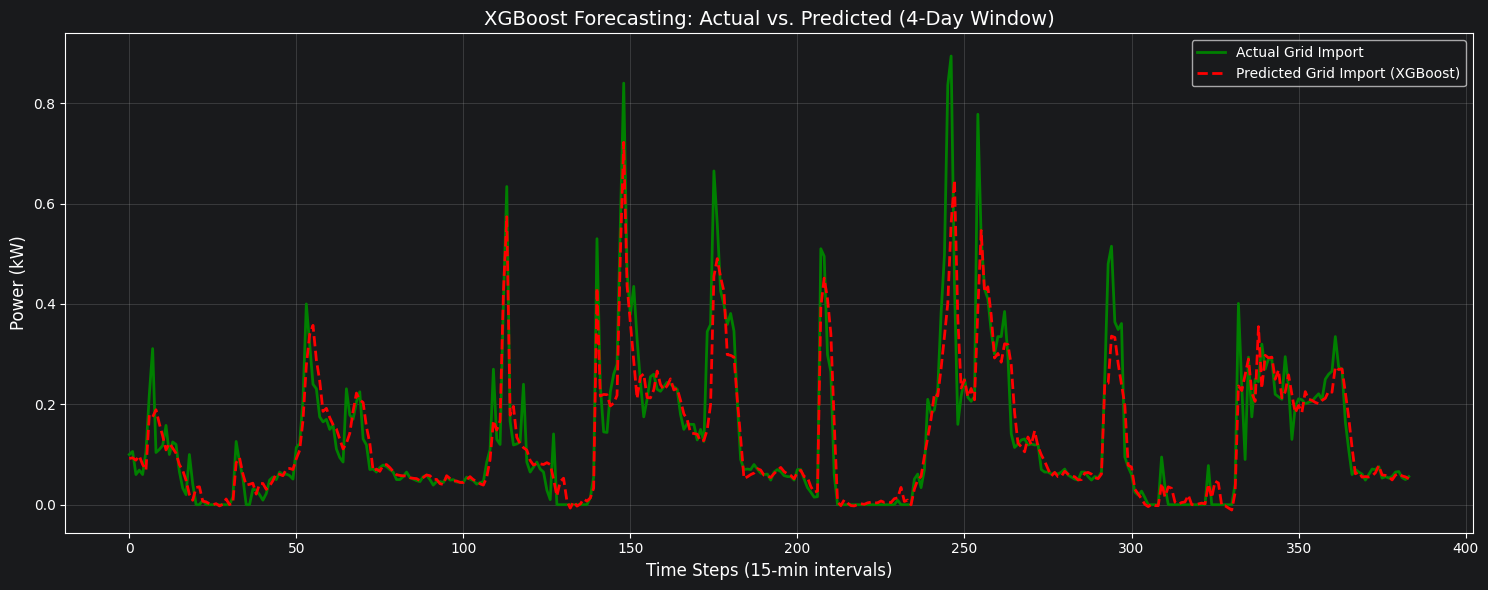

In [87]:
PLOT_STEPS = 384

plt.figure(figsize=(15, 6))

# FIX 1: Explicitly select the Grid Import column from the y_test DataFrame
plt.plot(y_test['DE_KN_residential3_grid_import'].values[:PLOT_STEPS],
         label='Actual Grid Import', color='green', linewidth=2)

# FIX 2: Slice the y_pred NumPy array to grab only Column 1 (Grid Import)
plt.plot(y_pred[:PLOT_STEPS, 1],
         label='Predicted Grid Import (XGBoost)', color='red', linestyle='--', linewidth=2)

plt.title('XGBoost Forecasting: Actual vs. Predicted (4-Day Window)', fontsize=14)
plt.ylabel('Power (kW)', fontsize=12)
plt.xlabel('Time Steps (15-min intervals)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

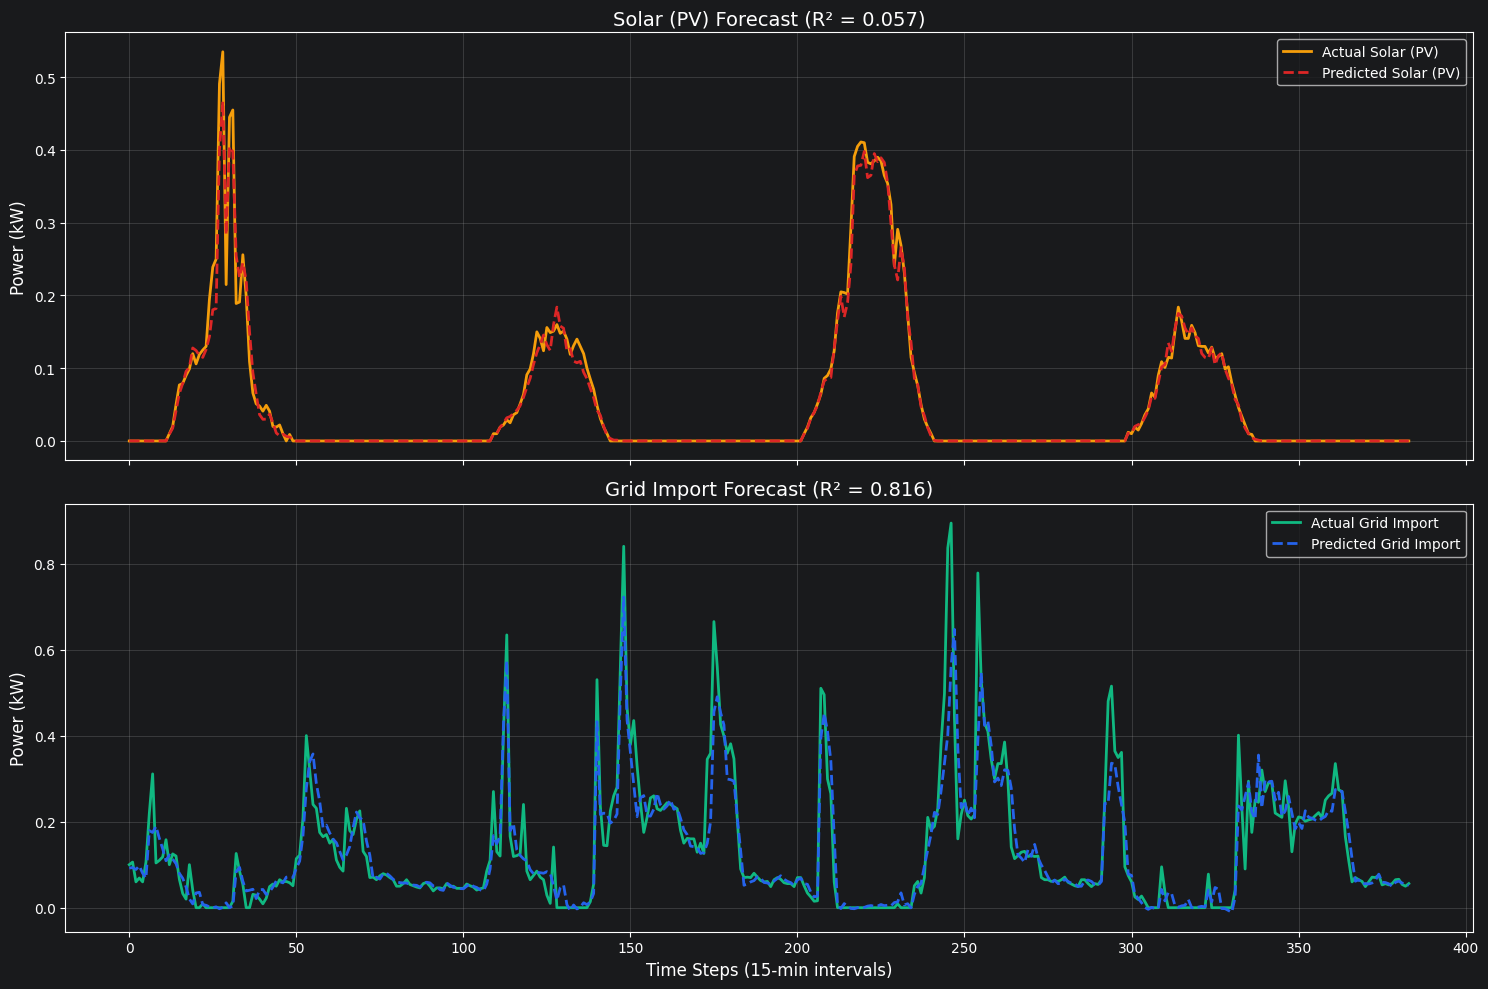

In [88]:
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Let's look at a 4-day window (96 steps/day * 4 = 384 steps)
PLOT_STEPS = 384

# Slice the arrays to only plot the first few days of the test set
# (Assuming pv_actual, pv_pred, grid_actual, grid_pred are still in memory from the evaluation cell)
pv_actual_plot = pv_actual[:PLOT_STEPS]
pv_pred_plot = pv_pred[:PLOT_STEPS]

grid_actual_plot = grid_actual[:PLOT_STEPS]
grid_pred_plot = grid_pred[:PLOT_STEPS]

# Create a figure with 2 subplots (stacked vertically)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

# ==========================================
# SUBPLOT 1: SOLAR (PV)
# ==========================================
axes[0].plot(pv_actual_plot, label='Actual Solar (PV)', color='#f59e0b', linewidth=2)
axes[0].plot(pv_pred_plot, label='Predicted Solar (PV)', color='#dc2626', linestyle='--', linewidth=2)

axes[0].set_title(f'Solar (PV) Forecast (R² = 0.057)', fontsize=14)
axes[0].set_ylabel('Power (kW)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ==========================================
# SUBPLOT 2: GRID IMPORT
# ==========================================
axes[1].plot(grid_actual_plot, label='Actual Grid Import', color='#10b981', linewidth=2)
axes[1].plot(grid_pred_plot, label='Predicted Grid Import', color='#2563eb', linestyle='--', linewidth=2)

axes[1].set_title(f'Grid Import Forecast (R² = 0.816)', fontsize=14)
axes[1].set_ylabel('Power (kW)', fontsize=12)
axes[1].set_xlabel('Time Steps (15-min intervals)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Adjust layout so the titles don't overlap
plt.tight_layout()
plt.show()